## PCA Implementation With Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [2]:
dataset=load_iris()

In [5]:
dataset

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [3]:
X=dataset['data']
y=dataset['target']

In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [14]:
## PCA- Transformation
pca=PCA(n_components=2)
pca

PCA(n_components=2)

In [15]:
new=pca.fit_transform(X_scaled)

In [18]:
pca.components_

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199]])

In [17]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

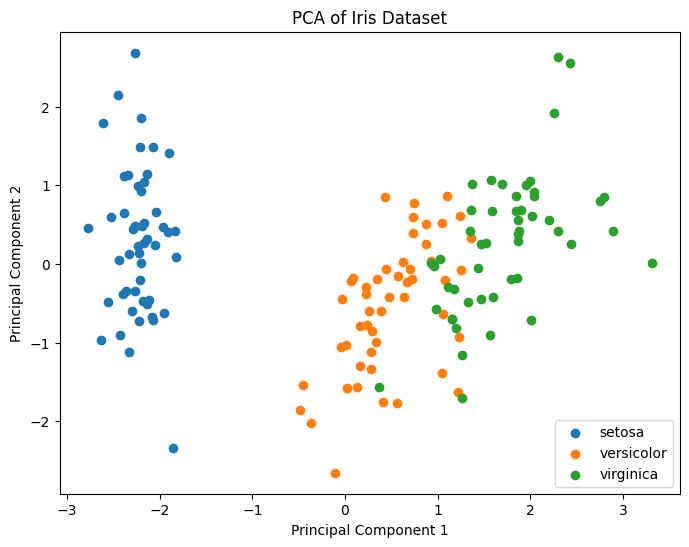

In [22]:
plt.figure(figsize=(8,6))
for i,target_name in enumerate(dataset.target_names):
    plt.scatter(new[y==i,0],new[y==i,1],label=target_name)
plt.title("PCA of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [23]:
from sklearn.datasets import fetch_openml

In [46]:
dataset=fetch_openml(name="wine-quality-white",version=1,as_frame=True)

C:\Users\Vikas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\datasets\_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [47]:
df=dataset.frame

In [29]:
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,Class
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,4
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,4
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,4
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,4
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,4
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,4
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,3
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,4
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,5


In [28]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'Class'],
      dtype='object')

In [30]:
df["Class"].unique()

['4', '3', '5', '6', '2', '1', '7']
Categories (7, object): ['1', '2', '3', '4', '5', '6', '7']

In [32]:
target_column="Class" if "Class" in df.columns else "quality"

In [34]:
x=df.drop(columns=[target_column])
y=df[target_column]

In [35]:
y=y.astype("category").cat.codes

In [36]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [43]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

In [44]:
pca.explained_variance_ratio_

array([0.29293217, 0.14320363])

In [45]:
pca.components_

array([[ 0.15721845,  0.00508949,  0.14404984,  0.42740837,  0.21201106,
         0.30033439,  0.4066522 ,  0.5115236 , -0.12883188,  0.04337933,
        -0.43723783],
       [-0.58755821,  0.05172805, -0.34529456,  0.00874939, -0.00880031,
         0.29035514,  0.24403239,  0.0062968 ,  0.5813444 ,  0.22269537,
        -0.03556867]])

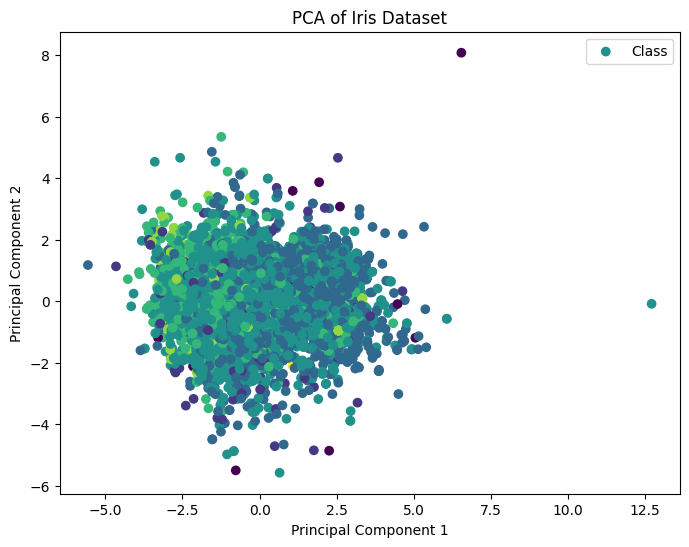

In [49]:
plt.figure(figsize=(8,6))
for i,target_name in enumerate(dataset.target_names):
    plt.scatter(x_pca[:,0],x_pca[:,1],label=target_name,c=y)
plt.title("PCA of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

Explained Variance Ratio: [0.72962445 0.22850762]


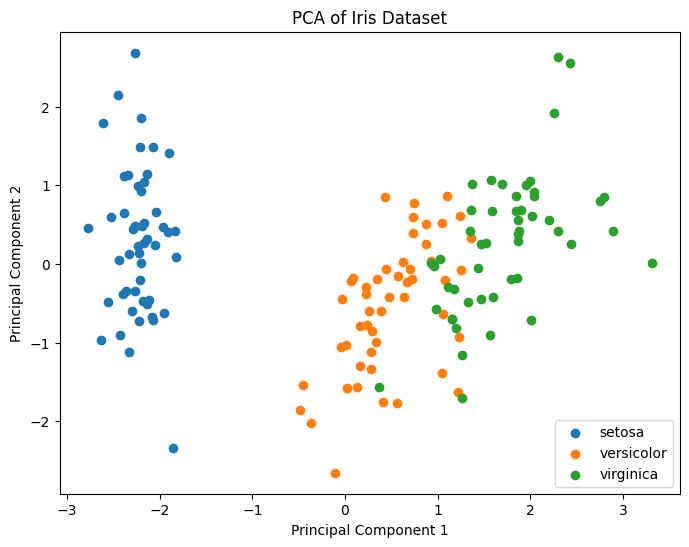

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
data = load_iris()
X = data.data  # Features
y = data.target  # Labels

# Standardize the dataset (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Plot the PCA result
plt.figure(figsize=(8, 6))
for i, target_name in enumerate(data.target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=target_name)
    
plt.title("PCA of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


C:\Users\Vikas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\datasets\_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Columns in dataset: Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'Class'],
      dtype='object')
    V1    V2    V3    V4     V5    V6     V7      V8    V9   V10   V11 Class
0  7.0  0.27  0.36  20.7  0.045  45.0  170.0  1.0010  3.00  0.45   8.8     4
1  6.3  0.30  0.34   1.6  0.049  14.0  132.0  0.9940  3.30  0.49   9.5     4
2  8.1  0.28  0.40   6.9  0.050  30.0   97.0  0.9951  3.26  0.44  10.1     4
3  7.2  0.23  0.32   8.5  0.058  47.0  186.0  0.9956  3.19  0.40   9.9     4
4  7.2  0.23  0.32   8.5  0.058  47.0  186.0  0.9956  3.19  0.40   9.9     4
Explained Variance Ratio: [0.29293217 0.14320363]


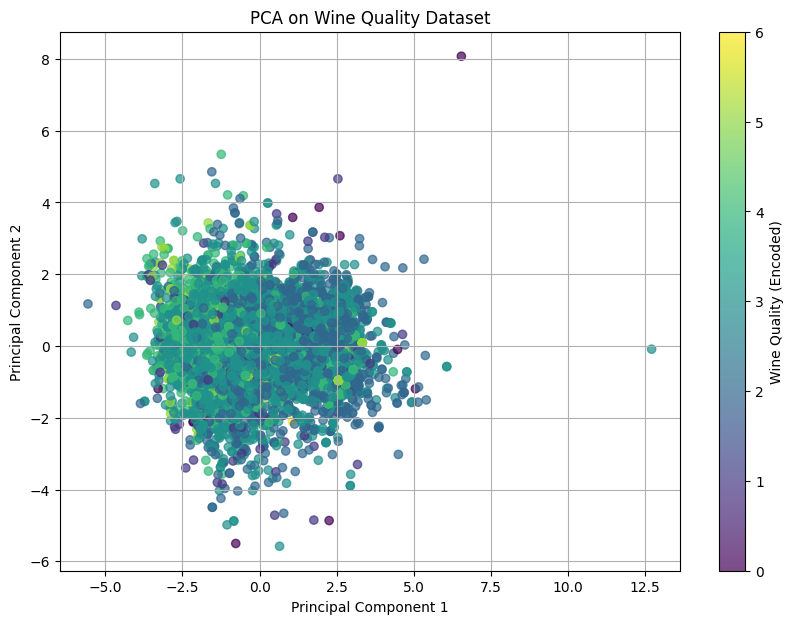

In [8]:
from sklearn.datasets import fetch_openml

# Load the Wine Quality dataset
wine_data = fetch_openml(name="wine-quality-white", version=1, as_frame=True)
df = wine_data.frame

# Check the column names and dataset structure
print("Columns in dataset:", df.columns)
print(df.head())

# Identify the target column
target_column = 'Class' if 'Class' in df.columns else 'quality'
if target_column not in df.columns:
    raise ValueError(f"Expected target column ('Class' or 'quality') not found in dataset.")

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Convert target column to numeric (if categorical)
y = y.astype("category").cat.codes

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 components
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)

# Create a scatter plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", alpha=0.7)
plt.colorbar(scatter, label="Wine Quality (Encoded)")
plt.title("PCA on Wine Quality Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()
